In [80]:
import pyMMF
import numpy as np
import matplotlib.pyplot as plt

In [81]:
NA = 0.275
radius = 2 # in microns
areaSize = 2.5*radius # calculate the field on an area larger than the diameter of the fiber
npoints = 2**7 # resolution of the window
n1 = 1.45
wl = 0.6328 # wavelength in microns
curvature = None

In [82]:
profile = pyMMF.IndexProfile(npoints = npoints, areaSize = areaSize)

In [83]:
profile.initStepIndex(n1=n1, a=radius, NA=NA)

In [84]:
solver = pyMMF.propagationModeSolver()
solver.setIndexProfile(profile)
solver.setWL(wl)

2024-01-12 14:50:33,645 - pyMMF.core [DEBUG  ]  Debug mode ON.


In [85]:
NmodesMax = pyMMF.estimateNumModesSI(wl,radius,NA,pola = 1)

In [86]:
modes = solver.solve (mode = 'SI', curvature = None)


2024-01-12 14:50:33,943 - pyMMF.solv [INFO   ]  Finding the propagation constant of step index fiber by numerically solving the dispersion relation.
2024-01-12 14:50:34,065 - pyMMF.solv [INFO   ]  Found 8 modes is 0.12 seconds.
2024-01-12 14:50:34,065 - pyMMF.solv [INFO   ]  Finding analytical LP mode profiles associated to the propagation constants.
2024-01-12 14:50:34,250 - pyMMF.core [DEBUG  ]  Mode data stored in memory.


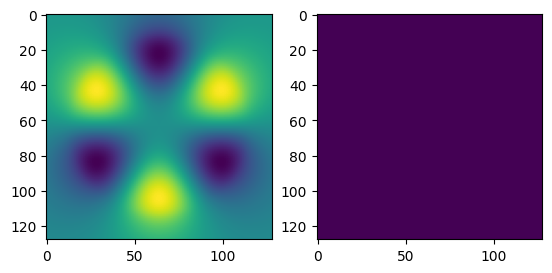

In [87]:
m = 7
plt.figure()
plt.subplot(121)
plt.imshow(np.real(modes.profiles[m]).reshape([npoints]*2))
plt.subplot(122)
plt.imshow(np.imag(modes.profiles[m]).reshape([npoints]*2))

C:\Users\psain\AppData\Local\Temp\ipykernel_3624\3542678310.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  superpos = np.sum(weights[i] * modes.profiles[i] for i in range(NmodesMax))


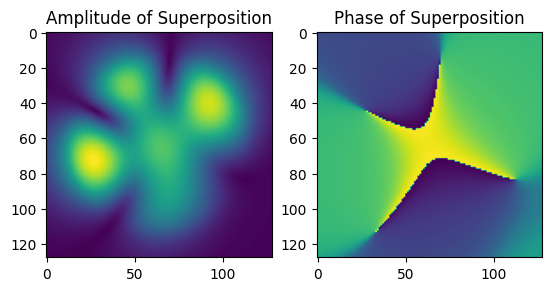

In [88]:
#Define weights for all modes
a = np.random.uniform(0, 1, size=NmodesMax)
phi = np.random.uniform(0, 2 * np.pi, size=NmodesMax)
weights = a * np.exp(1j * phi)

#Create Superposition
superpos = np.sum(weights[i] * modes.profiles[i] for i in range(NmodesMax))

# Visualize the superposition
plt.figure()
plt.subplot(121)
plt.imshow(np.abs(superpos).reshape([npoints] * 2))
plt.title('Amplitude of Superposition')

plt.subplot(122)
plt.imshow(np.angle(superpos).reshape([npoints] * 2))
plt.title('Phase of Superposition')

plt.show()

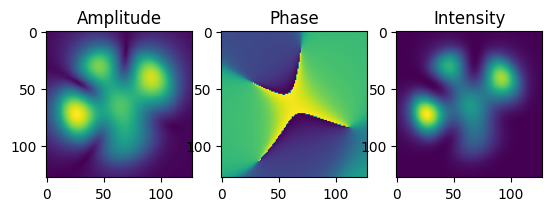

In [89]:
# Calculate intensity in MMF
intensity = superpos * np.conj(superpos)

# Visualize the results
plt.figure()
plt.subplot(131)
plt.imshow(np.abs(superpos).reshape([npoints] * 2))
plt.title('Amplitude')

plt.subplot(132)
plt.imshow(np.angle(superpos).reshape([npoints] * 2))
plt.title('Phase')

plt.subplot(133)
plt.imshow(np.abs(intensity).reshape([npoints] * 2))
plt.title('Intensity')

plt.show()

In [110]:


# Number of modes in the multimode fiber
total_modes = 8

# Initialize the vector with zeros
fiber_modes = np.zeros(total_modes, dtype=complex)

# Assign values for three modes (you can modify these values accordingly)
fiber_modes[0] = 0.5 * np.exp(1j * np.pi/4)
fiber_modes[3] = 0.8 * np.exp(1j * np.pi/3)
fiber_modes[7] = 0.3 * np.exp(1j * np.pi/2)

print("Multimode Fiber Modes:")
print(fiber_modes)


Multimode Fiber Modes:
[3.53553391e-01+0.35355339j 0.00000000e+00+0.j
 0.00000000e+00+0.j         4.00000000e-01+0.69282032j
 0.00000000e+00+0.j         0.00000000e+00+0.j
 0.00000000e+00+0.j         1.83697020e-17+0.3j       ]


In [111]:


# Set the number of modes and generate a random complex matrix
total_modes = 8
random_matrix = np.random.rand(total_modes, total_modes) + 1j * np.random.rand(total_modes, total_modes)

# Perform Singular Value Decomposition (SVD)
U, S, V = np.linalg.svd(random_matrix)

# Generate a random complex vector x with 10 modes
x = np.random.rand(total_modes) + 1j * np.random.rand(total_modes)

# Calculate the MMF output vector y as y = TM * x
TM = U
y = np.dot(TM, x)

# Display the results
print("Random complex matrix U from SVD:")        
print(U)
print("\n Random complex vector x:")
print(x)
print("\n MMF output vector y:")
print(y)


Random complex matrix U from SVD:
[[-0.182329  -1.81961373e-01j  0.22841215-1.43542369e-01j
  -0.18726724-1.87605427e-01j  0.38974793+1.73291022e-01j
   0.34714097+1.72240963e-02j -0.00763872-7.54743377e-02j
   0.02736671-1.55603316e-01j  0.55866164-3.80853272e-01j]
 [-0.22228225-2.61857646e-01j -0.17532777-3.46701400e-01j
   0.14926256-1.20423462e-01j -0.17921631+3.18714454e-01j
  -0.44061913-2.67979714e-01j -0.48739992-1.11399039e-01j
  -0.17046845-5.66482645e-02j  0.11133805-3.08489356e-03j]
 [-0.23153887-2.99414952e-01j -0.09591465+6.02870690e-01j
  -0.03125652-2.17610787e-01j -0.33313304-9.59950440e-03j
   0.19052166-2.58996513e-01j  0.06058076+3.83587222e-02j
  -0.27192597+3.15453065e-01j  0.0302807 -2.04441064e-01j]
 [-0.26937482-2.96070297e-01j -0.14740101+2.95210150e-01j
   0.14291137+7.07617595e-02j  0.00128194-1.68768708e-02j
  -0.08980378+2.96806313e-01j -0.03651263-3.43873401e-01j
   0.46184708-3.99079188e-01j -0.25868476-2.23518703e-01j]
 [-0.21571301-2.81497168e-01j  0.2

Random complex vector x:
[0.41111808+0.04008739j 0.68556544+0.17264338j 0.52669013+0.47802632j
 0.83172375+0.41895466j 0.25075043+0.61895724j 0.34020726+0.60660128j
 0.5472814 +0.43025552j 0.50135069+0.02832376j]

 MMF output vector y:
[ 0.84868671-0.08163015j -0.34350854-0.9628136j  -0.49666711+0.04404942j
  0.08973448-0.12287699j -0.11821797+0.42600467j -0.13071341-0.35428628j
  0.60179824+0.2854562j  -0.88034137-0.33119994j]

 Superposition of modes:
[ 0.00092771-0.00140929j  0.00093677-0.00142305j  0.00094427-0.00143444j
 ... -0.00094427+0.00143444j -0.00093677+0.00142305j
 -0.00092771+0.00140929j]


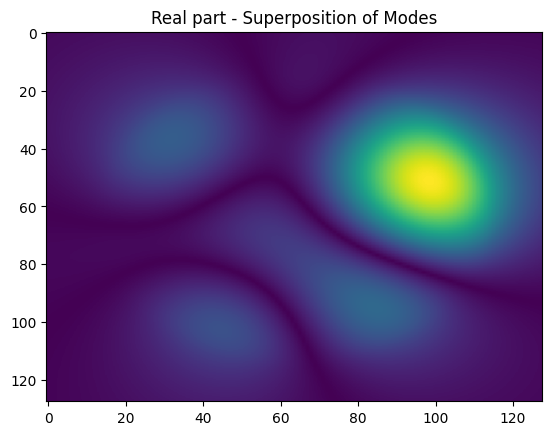

In [133]:

# Superposition of modes
superposition_y= np.sum(y) * np.sum([modes.profiles[i] for i in range(total_modes)],axis=0)

# Display the results
print("Random complex vector x:")
print(x)
print("\n MMF output vector y:")
print(y)
print("\n Superposition of modes:")
print(superposition)


plt.imshow(np.abs(superposition_y).reshape([npoints] * 2), aspect='auto', cmap='viridis')
plt.title('Real part - Superposition of Modes')
plt.show()


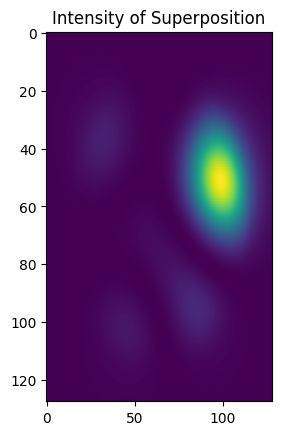

In [134]:
# Calculate the intensity
intensity = np.abs(superposition_y) ** 2

# Visualize the intensity

plt.subplot(1, 2, 2)
plt.imshow(intensity.reshape([npoints]*2), aspect='auto', cmap='viridis')
plt.title('Intensity of Superposition')

plt.show()

In [95]:
#Code for MultiMode Fibre

In [35]:
import pyMMF
import numpy as np
import matplotlib.pyplot as plt

In [36]:
NA = 0.275
radius = 6 # in microns
areaSize = 2.5*radius # calculate the field on an area larger than the diameter of the fiber
npoints = 2**7 # resolution of the window
n1 = 1.45
wl = 0.6328 # wavelength in microns
curvature = None

In [37]:
profile = pyMMF.IndexProfile(npoints = npoints, areaSize = areaSize)

In [38]:
profile.initStepIndex(n1=n1, a=radius, NA=NA)

In [39]:
solver = pyMMF.propagationModeSolver()
solver.setIndexProfile(profile)
solver.setWL(wl)

2023-12-26 12:35:40,866 - pyMMF.core [DEBUG  ]  Debug mode ON.


In [40]:
NmodesMax = pyMMF.estimateNumModesSI(wl,radius,NA,pola = 1)

In [41]:
modes = solver.solve (mode = 'SI', curvature = None)

2023-12-26 12:35:41,952 - pyMMF.solv [INFO   ]  Finding the propagation constant of step index fiber by numerically solving the dispersion relation.
2023-12-26 12:35:42,376 - pyMMF.solv [INFO   ]  Found 69 modes is 0.42 seconds.
2023-12-26 12:35:42,377 - pyMMF.solv [INFO   ]  Finding analytical LP mode profiles associated to the propagation constants.
2023-12-26 12:35:44,203 - pyMMF.core [DEBUG  ]  Mode data stored in memory.


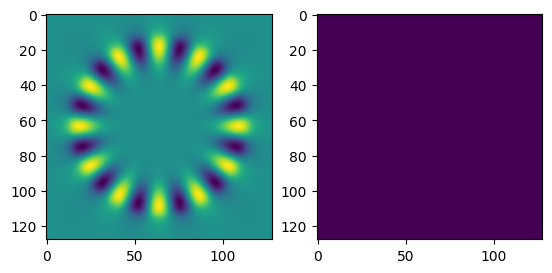

In [42]:
m = 67
plt.figure()
plt.subplot(121)
plt.imshow(np.real(modes.profiles[m]).reshape([npoints]*2))
plt.subplot(122)
plt.imshow(np.imag(modes.profiles[m]).reshape([npoints]*2))

In [43]:
#Define weights for all modes
a = np.random.uniform(0, 1, size=NmodesMax)
phi = np.random.uniform(0, 2 * np.pi, size=NmodesMax)
weights = a * np.exp(1j * phi)


In [44]:
#Create Superposition
superposition = np.sum(weights[i] * modes.profiles[i] for i in range(NmodesMax))

C:\Users\psain\AppData\Local\Temp\ipykernel_22648\702995975.py:2: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  superposition = np.sum(weights[i] * modes.profiles[i] for i in range(NmodesMax))


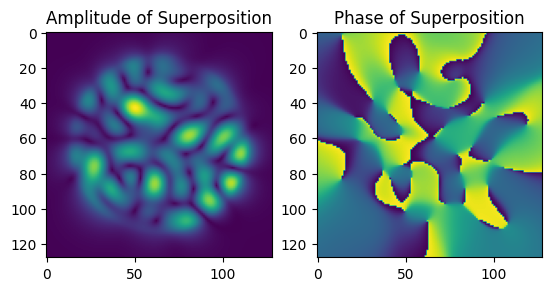

In [45]:
# Visualize the superposition
plt.figure()
plt.subplot(121)
plt.imshow(np.abs(superposition).reshape([npoints] * 2))
plt.title('Amplitude of Superposition')

plt.subplot(122)
plt.imshow(np.angle(superposition).reshape([npoints] * 2))
plt.title('Phase of Superposition')

plt.show()

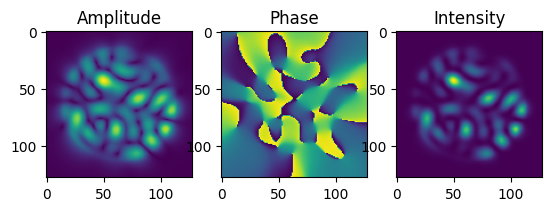

In [46]:
# Calculate intensity in FMF
intensity = superposition * np.conj(superposition)

# Visualize the results
plt.figure()
plt.subplot(131)
plt.imshow(np.abs(superposition).reshape([npoints] * 2))
plt.title('Amplitude')

plt.subplot(132)
plt.imshow(np.angle(superposition).reshape([npoints] * 2))
plt.title('Phase')

plt.subplot(133)
plt.imshow(np.abs(intensity).reshape([npoints] * 2))
plt.title('Intensity')

plt.show()